# Assignment Two: CNN for Image Colorization

**Name:** Laiba Bint-e-Zia
**Student ID:** 23k-0006

In this assignment we train CNNs to colorize grayscale images of horses from CIFAR-10. We try three approaches:
1. Colorization as **regression** (predict RGB values directly)
2. Colorization as **classification** (predict one of 24 colour categories)
3. Classification with **skip connections (UNet)**

## Setup

In [1]:
import os
import math
import time
import pickle
import sys
import tarfile

import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from PIL import Image
from six.moves.urllib.request import urlretrieve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

print('torch version:', torch.__version__)
print('gpu available:', torch.cuda.is_available())

torch version: 2.10.0+cu128
gpu available: True


## Helper Code (provided)

Data loading and utility functions, these were given to us, I didn't write these.

In [2]:
def get_file(fname, origin, untar=False, extract=False, archive_format='auto', cache_dir='data'):
    datadir = os.path.join(cache_dir)
    if not os.path.exists(datadir):
        os.makedirs(datadir)
    if untar:
        untar_fpath = os.path.join(datadir, fname)
        fpath = untar_fpath + '.tar.gz'
    else:
        fpath = os.path.join(datadir, fname)
    print(fpath)
    if not os.path.exists(fpath):
        print('Downloading data from', origin)
        try:
            urlretrieve(origin, fpath)
        except Exception as e:
            if os.path.exists(fpath):
                os.remove(fpath)
            raise
    if untar:
        if not os.path.exists(untar_fpath):
            print('Extracting file.')
            with tarfile.open(fpath) as archive:
                archive.extractall(datadir)
        return untar_fpath
    return fpath


def load_batch(fpath, label_key='labels'):
    with open(fpath, 'rb') as f:
        if sys.version_info < (3,):
            d = pickle.load(f)
        else:
            d = pickle.load(f, encoding='bytes')
            d = {k.decode('utf8'): v for k, v in d.items()}
    data = d['data'].reshape(d['data'].shape[0], 3, 32, 32)
    return data, d[label_key]


def load_cifar10(transpose=False):
    dirname = 'cifar-10-batches-py'
    origin = 'http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    path = get_file(dirname, origin=origin, untar=True)

    x_train = np.zeros((50000, 3, 32, 32), dtype='uint8')
    y_train = np.zeros((50000,), dtype='uint8')
    for i in range(1, 6):
        fpath = os.path.join(path, 'data_batch_' + str(i))
        data, labels = load_batch(fpath)
        x_train[(i-1)*10000: i*10000] = data
        y_train[(i-1)*10000: i*10000] = labels

    fpath = os.path.join(path, 'test_batch')
    x_test, y_test = load_batch(fpath)

    y_train = np.reshape(y_train, (len(y_train), 1))
    y_test = np.reshape(y_test, (len(y_test), 1))

    if transpose:
        x_train = x_train.transpose(0, 2, 3, 1)
        x_test = x_test.transpose(0, 2, 3, 1)
    return (x_train, y_train), (x_test, y_test)

In [3]:
# download data
colours_fpath = get_file(
    fname='colours',
    origin='http://www.cs.toronto.edu/~jba/kmeans_colour_a2.tar.gz',
    untar=True
)
m = load_cifar10()

data/colours.tar.gz
Extracting file.
data/cifar-10-batches-py.tar.gz


/tmp/ipykernel_4960/3155032633.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(datadir)


Extracting file.


In [4]:
HORSE_CATEGORY = 7

def get_rgb_cat(xs, colours):
    if np.shape(xs)[0] < 100:
        return _get_rgb_cat(xs, colours)
    batch_size = 100
    nexts = []
    for i in range(0, np.shape(xs)[0], batch_size):
        nexts.append(_get_rgb_cat(xs[i:i+batch_size], colours))
    return np.concatenate(nexts, axis=0)

def _get_rgb_cat(xs, colours):
    num_colours = np.shape(colours)[0]
    xs = np.expand_dims(xs, 0)
    cs = np.reshape(colours, [num_colours, 1, 3, 1, 1])
    dists = np.linalg.norm(xs - cs, axis=2)
    cat = np.argmin(dists, axis=0)
    return np.expand_dims(cat, axis=1)

def get_cat_rgb(cats, colours):
    return colours[cats]

def process(xs, ys, max_pixel=256.0):
    xs = xs / max_pixel
    xs = xs[np.where(ys == HORSE_CATEGORY)[0]]
    npr.shuffle(xs)
    grey = np.mean(xs, axis=1, keepdims=True)
    return xs, grey

def get_batch(x, y, batch_size):
    N = np.shape(x)[0]
    for i in range(0, N, batch_size):
        yield x[i:i+batch_size], y[i:i+batch_size]

def get_torch_vars(xs, ys, gpu=False):
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).float()
    if gpu:
        xs, ys = xs.cuda(), ys.cuda()
    return Variable(xs), Variable(ys)

def get_torch_vars_int(xs, ys, gpu=False):
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).long()
    if gpu:
        xs, ys = xs.cuda(), ys.cuda()
    return Variable(xs), Variable(ys)

def compute_loss(criterion, outputs, labels, batch_size, num_colours):
    loss_out = outputs.transpose(1,3).contiguous().view([batch_size*32*32, num_colours])
    loss_lab = labels.transpose(1,3).contiguous().view([batch_size*32*32])
    return criterion(loss_out, loss_lab)

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

In [5]:
# visualization helpers
def plot_regression(input, gtrgb, predrgb, path, visualize=False):
    k = 10
    grey = np.transpose(input[:k], [0,2,3,1])
    gtcolor = np.transpose(gtrgb[:k], [0,2,3,1])
    predcolor = np.transpose(predrgb[:k], [0,2,3,1])
    img = np.vstack([
        np.hstack(np.tile(grey, [1,1,1,3])),
        np.hstack(gtcolor),
        np.hstack(predcolor)
    ])
    plt.figure(figsize=(14,5))
    plt.axis('off')
    plt.imshow(img.clip(0,1))
    plt.title('Top: Grayscale Input | Middle: Ground Truth | Bottom: Predicted')
    if visualize:
        plt.show()
    else:
        plt.savefig(path)
        plt.show()

def plot_classification(input, gtlabel, output, colours, path, visualize=False):
    k = 10
    grey = np.transpose(input[:k], [0,2,3,1])
    gtcolor = get_cat_rgb(gtlabel[:k,0,:,:], colours)
    predcolor = get_cat_rgb(output[:k,0,:,:], colours)
    img = np.vstack([
        np.hstack(np.tile(grey, [1,1,1,3])),
        np.hstack(gtcolor),
        np.hstack(predcolor)
    ])
    plt.figure(figsize=(14,5))
    plt.axis('off')
    plt.imshow(img.clip(0,1))
    plt.title('Top: Grayscale Input | Middle: Ground Truth | Bottom: Predicted')
    if visualize:
        plt.show()
    else:
        plt.savefig(path)
        plt.show()

## Part 1: Colorization as Regression

The simplest approach: just treat it as a regression problem where we predict the 3 RGB values for each pixel directly from the grayscale input. We use MSE loss since the outputs are continuous.

### Regression CNN Architecture

The architecture follows an encoder decoder structure. The network first downsamples using MaxPool, processes at a lower resolution, then upsamples back to the original size.

| Layer | Type | Input Channels | Output Channels | Kernel | Other |
|-------|------|---------------|----------------|--------|-------|
| downconv1 | Conv2d + BN + ReLU + MaxPool2d | 1 | 32 | 3×3 | stride 2 via pool |
| downconv2 | Conv2d + BN + ReLU + MaxPool2d | 32 | 64 | 3×3 | stride 2 via pool |
| rfconv | Conv2d + BN + ReLU | 64 | 64 | 3×3 | same spatial size |
| upconv1 | Conv2d + BN + ReLU + Upsample | 64 | 32 | 3×3 | ×2 upsample |
| upconv2 | Conv2d + BN + ReLU + Upsample | 32 | 3 | 3×3 | ×2 upsample |
| finalconv | MyConv2d | 3 | 3 | 3×3 | output layer |

So there are **5 convolution layers** total (not counting the MyConv2d final which is also a conv). With `num_filters=32`: filters go 1→32→64→64→32→3→3.

In [6]:
class MyConv2d(nn.Module):
    """
    Custom conv2d implementation - same as nn.Conv2d but written manually
    so we can see how convolution actually works under the hood
    """
    def __init__(self, in_channels, out_channels, kernel_size, padding=None):
        super(MyConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2 if padding is None else padding
        self.weight = nn.parameter.Parameter(
            torch.Tensor(out_channels, in_channels, kernel_size, kernel_size))
        self.bias = nn.parameter.Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        n = self.in_channels * self.kernel_size * self.kernel_size
        stdv = 1. / math.sqrt(n)
        self.weight.data.uniform_(-stdv, stdv)
        self.bias.data.uniform_(-stdv, stdv)

    def forward(self, input):
        return F.conv2d(input, self.weight, self.bias, padding=self.padding)


class RegressionCNN(nn.Module):
    def __init__(self, kernel, num_filters):
        super(RegressionCNN, self).__init__()
        padding = kernel // 2

        self.downconv1 = nn.Sequential(
            nn.Conv2d(1, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        self.upconv1 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2))

        self.upconv2 = nn.Sequential(
            nn.Conv2d(num_filters, 3, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Upsample(scale_factor=2))

        self.finalconv = MyConv2d(3, 3, kernel_size=kernel)

    def forward(self, x):
        out = self.downconv1(x)
        out = self.downconv2(out)
        out = self.rfconv(out)
        out = self.upconv1(out)
        out = self.upconv2(out)
        out = self.finalconv(out)
        return out

In [7]:
def train_regression(args, cnn=None):
    torch.set_num_threads(5)
    npr.seed(args.seed)
    save_dir = 'outputs/' + args.experiment_name
    os.makedirs(save_dir, exist_ok=True)

    if cnn is None:
        cnn = RegressionCNN(args.kernel, args.num_filters)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=args.learn_rate)

    print('Loading data...')
    (x_train, y_train), (x_test, y_test) = load_cifar10()
    train_rgb, train_grey = process(x_train, y_train)
    test_rgb, test_grey = process(x_test, y_test)

    if args.gpu:
        cnn.cuda()

    train_losses, val_losses = [], []
    start = time.time()
    print('Training...')
    for epoch in range(args.epochs):
        cnn.train()
        epoch_losses = []
        for xs, ys in get_batch(train_grey, train_rgb, args.batch_size):
            images, labels = get_torch_vars(xs, ys, args.gpu)
            optimizer.zero_grad()
            outputs = cnn(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.data.item())

        avg_train_loss = np.mean(epoch_losses)
        train_losses.append(avg_train_loss)

        cnn.eval()
        val_loss_list = []
        with torch.no_grad():
            for xs, ys in get_batch(test_grey, test_rgb, args.batch_size):
                images, labels = get_torch_vars(xs, ys, args.gpu)
                outputs = cnn(images)
                val_loss_list.append(criterion(outputs, labels).item())
        avg_val_loss = np.mean(val_loss_list)
        val_losses.append(avg_val_loss)

        print(f'Epoch [{epoch+1}/{args.epochs}]  Train Loss: {avg_train_loss:.4f}  Val Loss: {avg_val_loss:.4f}  Time: {int(time.time()-start)}s')

    # plot training curve
    plt.figure(figsize=(8,4))
    plt.plot(train_losses, 'ro-', label='Train')
    plt.plot(val_losses, 'go-', label='Validation')
    plt.legend()
    plt.title('Regression CNN - Training Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.savefig(save_dir + '/training_curve.png')
    plt.show()

    # generate predictions on last batch
    cnn.eval()
    with torch.no_grad():
        images, labels = get_torch_vars(test_grey[:10], test_rgb[:10], args.gpu)
        preds = cnn(images).cpu().data.numpy()
    plot_regression(test_grey[:10], test_rgb[:10], preds,
                    save_dir + '/regression_output.png', visualize=True)

    return cnn, train_losses, val_losses

Loading data...
data/cifar-10-batches-py.tar.gz
Training...
Epoch [1/25]  Train Loss: 0.2216  Val Loss: 0.0910  Time: 1s
Epoch [2/25]  Train Loss: 0.0468  Val Loss: 0.0283  Time: 2s
Epoch [3/25]  Train Loss: 0.0230  Val Loss: 0.0204  Time: 2s
Epoch [4/25]  Train Loss: 0.0190  Val Loss: 0.0180  Time: 2s
Epoch [5/25]  Train Loss: 0.0173  Val Loss: 0.0166  Time: 3s
Epoch [6/25]  Train Loss: 0.0162  Val Loss: 0.0156  Time: 3s
Epoch [7/25]  Train Loss: 0.0152  Val Loss: 0.0147  Time: 3s
Epoch [8/25]  Train Loss: 0.0145  Val Loss: 0.0140  Time: 4s
Epoch [9/25]  Train Loss: 0.0138  Val Loss: 0.0135  Time: 4s
Epoch [10/25]  Train Loss: 0.0133  Val Loss: 0.0130  Time: 4s
Epoch [11/25]  Train Loss: 0.0128  Val Loss: 0.0125  Time: 5s
Epoch [12/25]  Train Loss: 0.0124  Val Loss: 0.0121  Time: 5s
Epoch [13/25]  Train Loss: 0.0120  Val Loss: 0.0118  Time: 5s
Epoch [14/25]  Train Loss: 0.0117  Val Loss: 0.0115  Time: 6s
Epoch [15/25]  Train Loss: 0.0114  Val Loss: 0.0112  Time: 6s
Epoch [16/25]  Trai

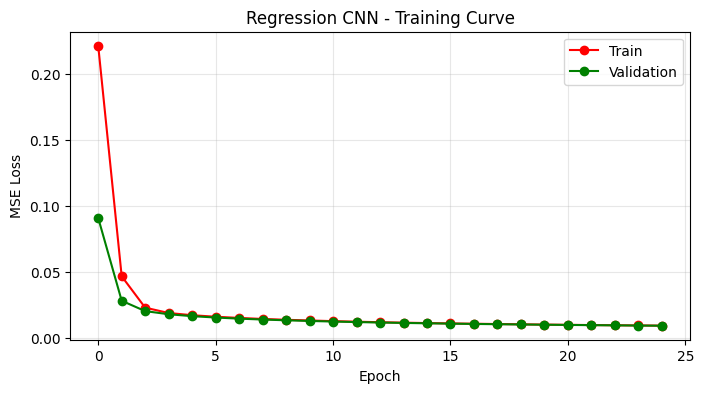

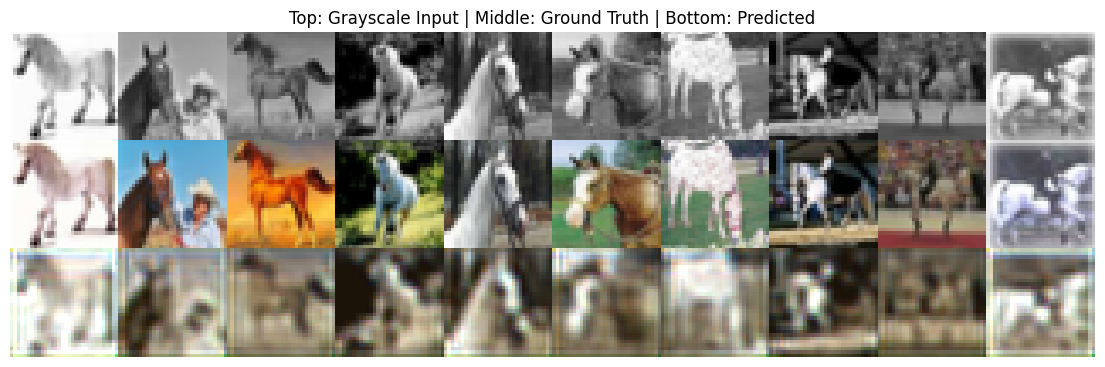

In [8]:
args = AttrDict()
args.update({
    'gpu': torch.cuda.is_available(),
    'checkpoint': '',
    'kernel': 3,
    'num_filters': 32,
    'learn_rate': 0.001,
    'batch_size': 100,
    'epochs': 25,
    'seed': 0,
    'experiment_name': 'regression_cnn',
    'visualize': False,
})

regression_cnn, reg_train_losses, reg_val_losses = train_regression(args)

### Training Variations: Effect of Number of Epochs

Here I retrain the same model with fewer epochs to see how training duration affects output quality.

Loading data...
data/cifar-10-batches-py.tar.gz
Training...
Epoch [1/5]  Train Loss: 0.3343  Val Loss: 0.1527  Time: 0s
Epoch [2/5]  Train Loss: 0.0929  Val Loss: 0.0526  Time: 0s
Epoch [3/5]  Train Loss: 0.0367  Val Loss: 0.0280  Time: 1s
Epoch [4/5]  Train Loss: 0.0245  Val Loss: 0.0214  Time: 1s
Epoch [5/5]  Train Loss: 0.0199  Val Loss: 0.0183  Time: 1s


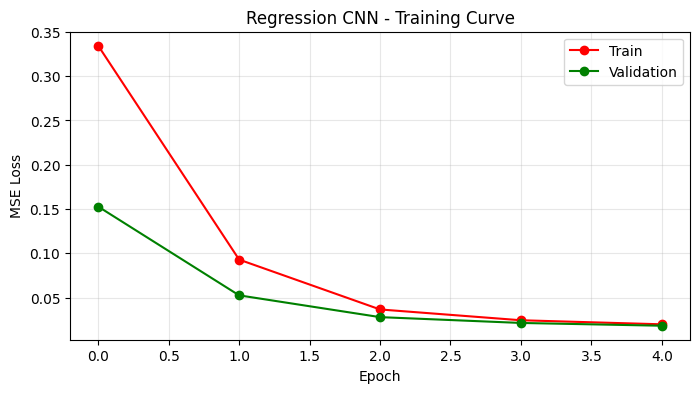

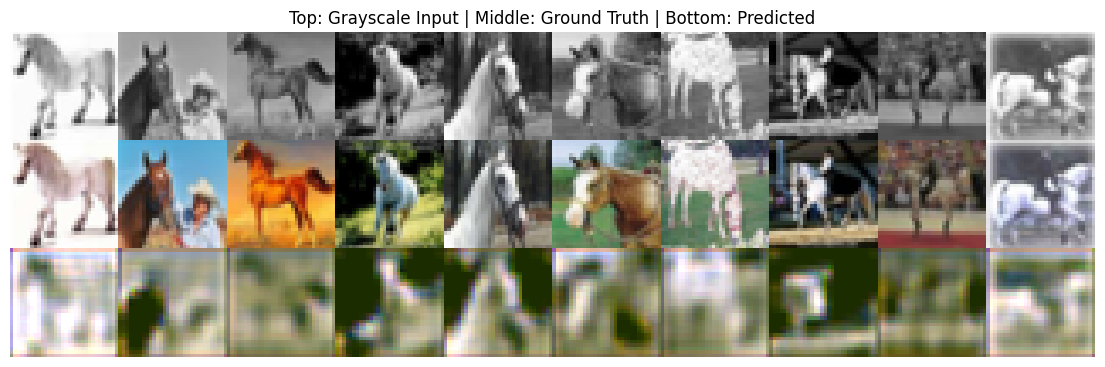

done with 5 epoch model


In [9]:
# train with fewer epochs to compare
args_5 = AttrDict()
args_5.update({
    'gpu': torch.cuda.is_available(),
    'checkpoint': '',
    'kernel': 3,
    'num_filters': 32,
    'learn_rate': 0.001,
    'batch_size': 100,
    'epochs': 5,
    'seed': 0,
    'experiment_name': 'regression_cnn_5ep',
    'visualize': False,
})
cnn_5ep, losses_5ep_train, losses_5ep_val = train_regression(args_5)
print('done with 5 epoch model')

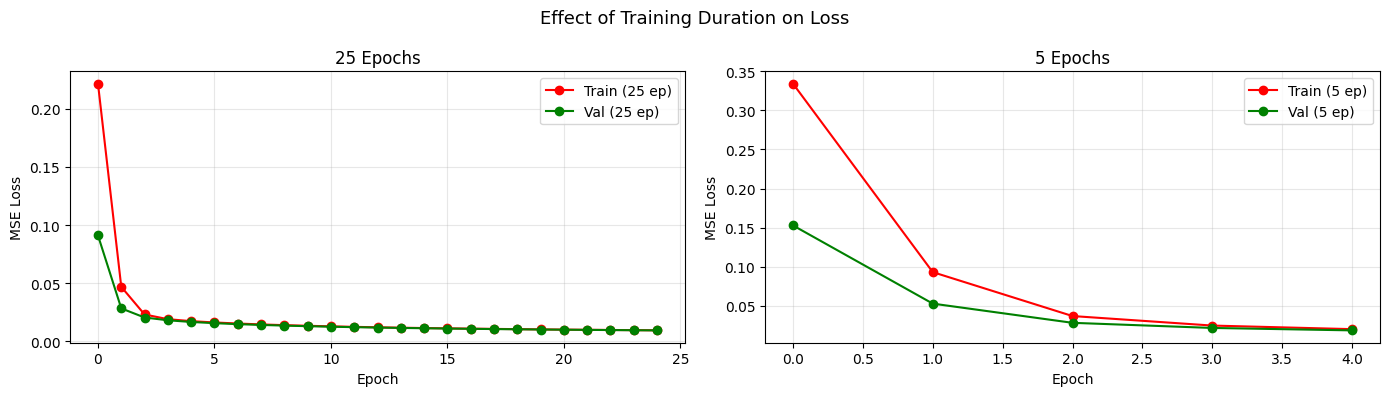

25 epoch final val loss: 0.0093
5 epoch final val loss:  0.0183


In [10]:
# compare loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(reg_train_losses, 'r-o', label='Train (25 ep)')
axes[0].plot(reg_val_losses, 'g-o', label='Val (25 ep)')
axes[0].set_title('25 Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses_5ep_train, 'r-o', label='Train (5 ep)')
axes[1].plot(losses_5ep_val, 'g-o', label='Val (5 ep)')
axes[1].set_title('5 Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effect of Training Duration on Loss', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/epoch_comparison.png', dpi=150)
plt.show()

print(f'25 epoch final val loss: {reg_val_losses[-1]:.4f}')
print(f'5 epoch final val loss:  {losses_5ep_val[-1]:.4f}')

**Observations on training duration:**  
As expected, training for more epochs leads to a lower loss and visually better colorizations. The 5-epoch model produces images that look mostly brown/grayish because it hasn't learned enough to predict diverse colours. The 25-epoch model does noticeably better - the horses start getting some correct colour tones. That said, regression is still limited because the MSE loss tends to average out colours, which is why the outputs can look washed out even after training long enough.

## Part 2: Colorization as Classification

Instead of predicting exact RGB values, we discretize the colour space into 24 clusters (using k means, stored in the .npy file) and predict which cluster each pixel belongs to. This is now a per pixel classification problem using CrossEntropy loss.

The idea is that classification might work better than regression because averaging over possible colours (which MSE encourages) leads to dull/gray results, while classification forces the network to commit to a specific colour.

number of colour categories: 24
colour array shape: (24, 3)


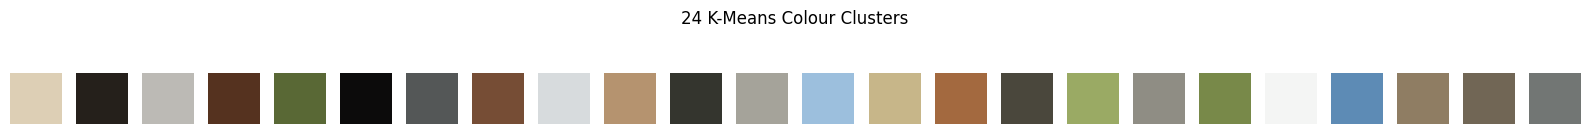

In [15]:
# load the 24 colour cluster centers
colours = np.load('./colour_kmeans24_cat7.npy', allow_pickle=True, encoding='bytes')[0]
num_colours = np.shape(colours)[0]
print('number of colour categories:', num_colours)
print('colour array shape:', colours.shape)

# visualize the 24 colours
fig, axes = plt.subplots(1, num_colours, figsize=(16, 1.5))
for i, ax in enumerate(axes):
    ax.imshow([[colours[i]]])
    ax.axis('off')
plt.suptitle('24 K-Means Colour Clusters', fontsize=12)
plt.tight_layout()
plt.show()

### Classification CNN

Same architecture as the regression CNN but the output layer now predicts `num_colours` classes instead of 3 RGB values. The assignment says to use `MyConv2d` instead of `nn.Conv2d`.

In [16]:
class CNN(nn.Module):
    def __init__(self, kernel, num_filters, num_colours, num_in_channels):
        super(CNN, self).__init__()
        padding = kernel // 2

        self.downconv1 = nn.Sequential(
            MyConv2d(num_in_channels, num_filters, kernel_size=kernel),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.downconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters*2, kernel_size=kernel),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.rfconv = nn.Sequential(
            MyConv2d(num_filters*2, num_filters*2, kernel_size=kernel),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        self.upconv1 = nn.Sequential(
            MyConv2d(num_filters*2, num_filters, kernel_size=kernel),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2))

        self.upconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters, kernel_size=kernel),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2))

        self.finalconv = MyConv2d(num_filters, num_colours, kernel_size=kernel)

    def forward(self, x):
        self.out1 = self.downconv1(x)
        self.out2 = self.downconv2(self.out1)
        self.out3 = self.rfconv(self.out2)
        self.out4 = self.upconv1(self.out3)
        self.out5 = self.upconv2(self.out4)
        self.out_final = self.finalconv(self.out5)
        return self.out_final

In [20]:
def run_validation_step(cnn, criterion, test_grey, test_rgb_cat, batch_size, colours, gpu=False):
    correct = 0.0
    total = 0.0
    losses = []
    num_colours = np.shape(colours)[0]
    cnn.eval()
    with torch.no_grad():
        for xs, ys in get_batch(test_grey, test_rgb_cat, batch_size):
            images, labels = get_torch_vars_int(xs, ys, gpu)
            outputs = cnn(images)
            val_loss = compute_loss(criterion, outputs, labels, batch_size=xs.shape[0], num_colours=num_colours)
            losses.append(val_loss.item())
            _, predicted = torch.max(outputs.data, 1, keepdim=True)
            total += labels.size(0) * 32 * 32
            correct += (predicted == labels.data).sum().item()
    return np.mean(losses), 100.0 * correct / total


def train_classification(args, cnn=None):
    torch.set_num_threads(5)
    npr.seed(args.seed)
    save_dir = 'outputs/' + args.experiment_name
    os.makedirs(save_dir, exist_ok=True)

    colours = np.load(args.colours, allow_pickle=True, encoding='latin1')[0]
    num_colours = np.shape(colours)[0]
    num_in_channels = 1

    if cnn is None:
        if args.model == 'CNN':
            cnn = CNN(args.kernel, args.num_filters, num_colours, num_in_channels)
        elif args.model == 'UNet':
            cnn = UNet(args.kernel, args.num_filters, num_colours, num_in_channels)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=args.learn_rate)

    print('Loading data...')
    (x_train, y_train), (x_test, y_test) = load_cifar10()
    train_rgb, train_grey = process(x_train, y_train)
    train_rgb_cat = get_rgb_cat(train_rgb, colours)
    test_rgb, test_grey = process(x_test, y_test)
    test_rgb_cat = get_rgb_cat(test_rgb, colours)

    if args.gpu:
        cnn.cuda()

    train_losses, val_losses, val_accs = [], [], []
    start = time.time()
    print('Training...')

    for epoch in range(args.epochs):
        cnn.train()
        epoch_losses = []
        for xs, ys in get_batch(train_grey, train_rgb_cat, args.batch_size):
            images, labels = get_torch_vars_int(xs, ys, args.gpu)
            optimizer.zero_grad()
            outputs = cnn(images)
            loss = compute_loss(criterion, outputs, labels,
                                batch_size=xs.shape[0], num_colours=num_colours)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)

        val_loss, val_acc = run_validation_step(
            cnn, criterion, test_grey, test_rgb_cat, args.batch_size, colours, args.gpu)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'Epoch [{epoch+1}/{args.epochs}]  Loss: {avg_loss:.4f}  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.1f}%  Time: {int(time.time()-start)}s')

    # training curve
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, 'ro-', label='Train')
    plt.plot(val_losses, 'go-', label='Validation')
    plt.legend()
    plt.title(f'{args.model} - Training Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.grid(True, alpha=0.3)
    plt.savefig(save_dir + '/training_curve.png')
    plt.show()

    # visualize outputs
    cnn.eval()
    with torch.no_grad():
        images, _ = get_torch_vars_int(test_grey[:10], test_rgb_cat[:10], args.gpu)
        outputs = cnn(images)
        _, predicted = torch.max(outputs.data, 1, keepdim=True)
    plot_classification(test_grey[:10], test_rgb_cat[:10], predicted.cpu().numpy(),
                        colours, save_dir + '/test_output.png', visualize=True)

    return cnn, train_losses, val_losses, val_accs

Loading data...
data/cifar-10-batches-py.tar.gz
Training...
Epoch [1/25]  Loss: 2.3909  Val Loss: 2.0842  Val Acc: 29.5%  Time: 0s
Epoch [2/25]  Loss: 1.9689  Val Loss: 1.8763  Val Acc: 34.1%  Time: 1s
Epoch [3/25]  Loss: 1.8572  Val Loss: 1.8031  Val Acc: 35.4%  Time: 2s
Epoch [4/25]  Loss: 1.7963  Val Loss: 1.7516  Val Acc: 37.0%  Time: 2s
Epoch [5/25]  Loss: 1.7555  Val Loss: 1.7177  Val Acc: 37.9%  Time: 3s
Epoch [6/25]  Loss: 1.7250  Val Loss: 1.6924  Val Acc: 38.5%  Time: 3s
Epoch [7/25]  Loss: 1.7016  Val Loss: 1.6766  Val Acc: 38.9%  Time: 4s
Epoch [8/25]  Loss: 1.6829  Val Loss: 1.6622  Val Acc: 39.2%  Time: 5s
Epoch [9/25]  Loss: 1.6677  Val Loss: 1.6583  Val Acc: 39.2%  Time: 5s
Epoch [10/25]  Loss: 1.6545  Val Loss: 1.6529  Val Acc: 39.1%  Time: 6s
Epoch [11/25]  Loss: 1.6434  Val Loss: 1.6452  Val Acc: 39.3%  Time: 6s
Epoch [12/25]  Loss: 1.6334  Val Loss: 1.6364  Val Acc: 39.7%  Time: 7s
Epoch [13/25]  Loss: 1.6239  Val Loss: 1.6286  Val Acc: 39.9%  Time: 8s
Epoch [14/25]

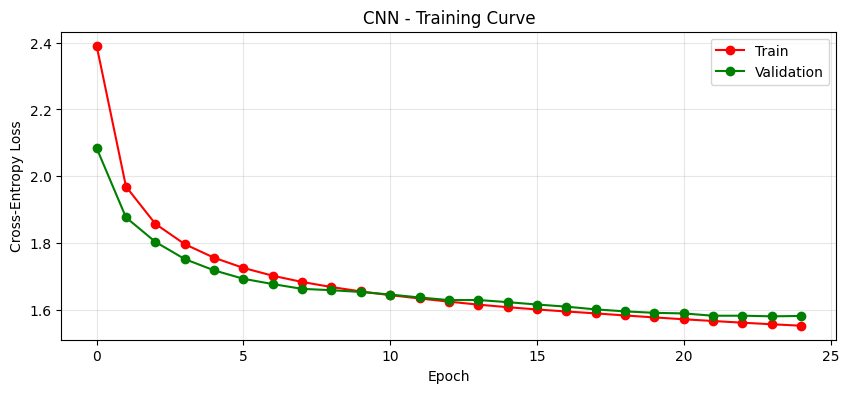

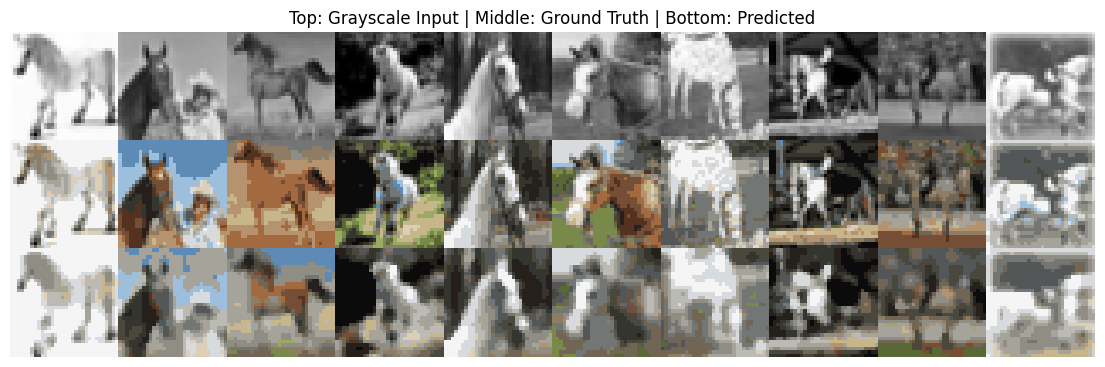

In [21]:
args_cnn = AttrDict()
args_cnn.update({
    'gpu': torch.cuda.is_available(),
    'checkpoint': '',
    'colours': './colour_kmeans24_cat7.npy',
    'model': 'CNN',
    'kernel': 3,
    'num_filters': 32,
    'learn_rate': 0.001,
    'batch_size': 100,
    'epochs': 25,
    'seed': 0,
    'experiment_name': 'colourization_cnn',
    'visualize': False,
})

cnn_model, cnn_train_losses, cnn_val_losses, cnn_val_accs = train_classification(args_cnn)

## Part 3: Skip Connections (UNet)

A UNet adds skip connections that connect encoder layers directly to corresponding decoder layers. The idea is that this lets the network preserve fine spatial detail that gets lost during downsampling. The first encoder layer connects to the last decoder layer, the second connects to the second last, and so on.

This means the final decoder layers receive both:
- the upsampled feature maps from the previous layer
- the original high resolution features from the encoder

The channels get concatenated, so we need to adjust the input channels accordingly.

In [22]:
class UNet(nn.Module):
    def __init__(self, kernel, num_filters, num_colours, num_in_channels):
        super(UNet, self).__init__()

        # encoder - same as CNN
        self.downconv1 = nn.Sequential(
            MyConv2d(num_in_channels, num_filters, kernel_size=kernel),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.downconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters*2, kernel_size=kernel),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.rfconv = nn.Sequential(
            MyConv2d(num_filters*2, num_filters*2, kernel_size=kernel),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        # decoder - input channels are doubled because of skip connections
        # upconv1 gets rfconv output + downconv2 output => num_filters*2 + num_filters*2
        self.upconv1 = nn.Sequential(
            MyConv2d(num_filters*4, num_filters, kernel_size=kernel),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2))

        # upconv2 gets upconv1 output + downconv1 output => num_filters + num_filters
        self.upconv2 = nn.Sequential(
            MyConv2d(num_filters*2, num_filters, kernel_size=kernel),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2))

        # final layer also gets skip from input (num_in_channels)
        self.finalconv = MyConv2d(num_filters + num_in_channels, num_colours, kernel_size=kernel)

    def forward(self, x):
        self.out1 = self.downconv1(x)                                    # 32x16x16
        self.out2 = self.downconv2(self.out1)                            # 64x8x8
        self.out3 = self.rfconv(self.out2)                               # 64x8x8
        # skip: concat out3 with out2
        self.out4 = self.upconv1(torch.cat([self.out3, self.out2], dim=1))  # 32x16x16
        # skip: concat out4 with out1
        self.out5 = self.upconv2(torch.cat([self.out4, self.out1], dim=1))  # 32x32x32
        # skip: concat out5 with original input x
        self.out_final = self.finalconv(torch.cat([self.out5, x], dim=1))   # 24x32x32
        return self.out_final

Loading data...
data/cifar-10-batches-py.tar.gz
Training...
Epoch [1/25]  Loss: 2.2757  Val Loss: 1.9778  Val Acc: 32.1%  Time: 0s
Epoch [2/25]  Loss: 1.8197  Val Loss: 1.7315  Val Acc: 37.4%  Time: 1s
Epoch [3/25]  Loss: 1.6928  Val Loss: 1.6325  Val Acc: 40.1%  Time: 2s
Epoch [4/25]  Loss: 1.6226  Val Loss: 1.5768  Val Acc: 41.8%  Time: 2s
Epoch [5/25]  Loss: 1.5707  Val Loss: 1.5350  Val Acc: 42.9%  Time: 3s
Epoch [6/25]  Loss: 1.5301  Val Loss: 1.5066  Val Acc: 43.6%  Time: 4s
Epoch [7/25]  Loss: 1.4967  Val Loss: 1.4839  Val Acc: 44.1%  Time: 4s
Epoch [8/25]  Loss: 1.4679  Val Loss: 1.4592  Val Acc: 44.9%  Time: 5s
Epoch [9/25]  Loss: 1.4429  Val Loss: 1.4428  Val Acc: 45.4%  Time: 6s
Epoch [10/25]  Loss: 1.4205  Val Loss: 1.4265  Val Acc: 45.8%  Time: 7s
Epoch [11/25]  Loss: 1.3998  Val Loss: 1.4126  Val Acc: 46.2%  Time: 7s
Epoch [12/25]  Loss: 1.3817  Val Loss: 1.3956  Val Acc: 46.8%  Time: 8s
Epoch [13/25]  Loss: 1.3647  Val Loss: 1.3847  Val Acc: 47.0%  Time: 9s
Epoch [14/25]

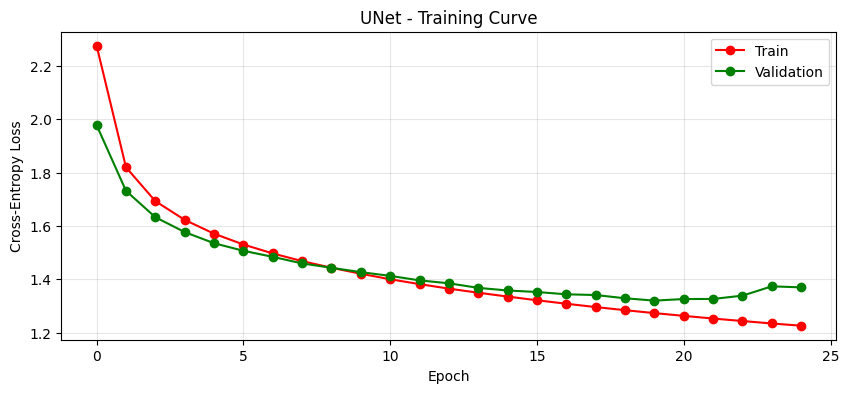

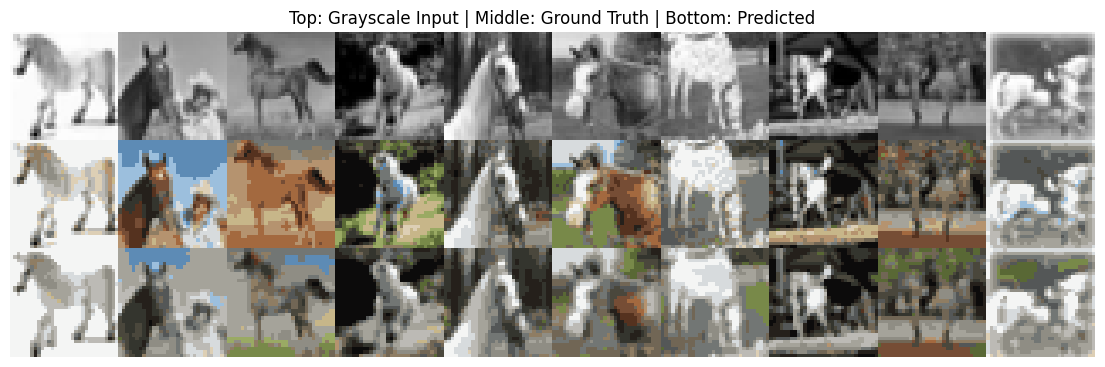

In [23]:
args_unet = AttrDict()
args_unet.update({
    'gpu': torch.cuda.is_available(),
    'checkpoint': '',
    'colours': './data/colours/colour_kmeans24_cat7.npy',
    'model': 'UNet',
    'kernel': 3,
    'num_filters': 32,
    'learn_rate': 0.001,
    'batch_size': 100,
    'epochs': 25,
    'seed': 0,
    'experiment_name': 'colourization_unet',
    'visualize': False,
})

unet_model, unet_train_losses, unet_val_losses, unet_val_accs = train_classification(args_unet)

### Comparing CNN vs UNet

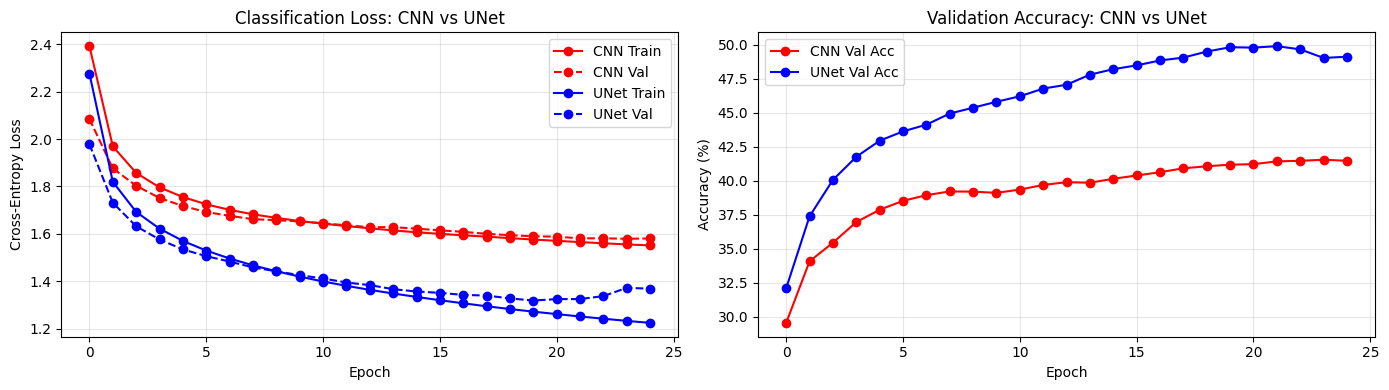

CNN  - Final Val Loss: 1.5811  Val Acc: 41.5%
UNet - Final Val Loss: 1.3695  Val Acc: 49.1%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(cnn_train_losses, 'r-o', label='CNN Train')
axes[0].plot(cnn_val_losses, 'r--o', label='CNN Val')
axes[0].plot(unet_train_losses, 'b-o', label='UNet Train')
axes[0].plot(unet_val_losses, 'b--o', label='UNet Val')
axes[0].set_title('Classification Loss: CNN vs UNet')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_val_accs, 'r-o', label='CNN Val Acc')
axes[1].plot(unet_val_accs, 'b-o', label='UNet Val Acc')
axes[1].set_title('Validation Accuracy: CNN vs UNet')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/cnn_vs_unet.png', dpi=150)
plt.show()

print(f'CNN  - Final Val Loss: {cnn_val_losses[-1]:.4f}  Val Acc: {cnn_val_accs[-1]:.1f}%')
print(f'UNet - Final Val Loss: {unet_val_losses[-1]:.4f}  Val Acc: {unet_val_accs[-1]:.1f}%')


## Part 4: Visualizing Intermediate Activations

Looking at what each layer of the network responds to.

In [25]:
def draw_activations(tensor, title, max_filters=16):
    """
    Draw the activation maps from a layer.
    tensor shape: [1, C, H, W]
    """
    act = tensor.data.cpu().numpy()[0]  # [C, H, W]
    n = min(act.shape[0], max_filters)
    cols = 8
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        axes[i].imshow(act[i], cmap='viridis')
        axes[i].axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


def visualize_activations(model, test_grey, test_rgb_cat, colours, idx=0, gpu=False):
    model.eval()
    model.cpu()

    sample_grey = np.expand_dims(test_grey[idx], 0)
    sample_cat = np.expand_dims(test_rgb_cat[idx], 0)
    images, _ = get_torch_vars_int(sample_grey, sample_cat, gpu=False)

    with torch.no_grad():
        _ = model(images)

    # show input
    plt.figure(figsize=(3,3))
    plt.imshow(test_grey[idx,0], cmap='gray')
    plt.title('Input (Grayscale)')
    plt.axis('off')
    plt.show()

    draw_activations(model.out1, 'Layer 1 (downconv1) - early features, 16x16')
    draw_activations(model.out2, 'Layer 2 (downconv2) - more abstract, 8x8')
    draw_activations(model.out3, 'Layer 3 (rfconv) - processed features, 8x8')
    draw_activations(model.out4, 'Layer 4 (upconv1) - decoding, 16x16')
    draw_activations(model.out5, 'Layer 5 (upconv2) - near output, 32x32')

data/cifar-10-batches-py.tar.gz
Activations for CNN:


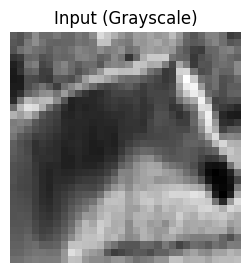

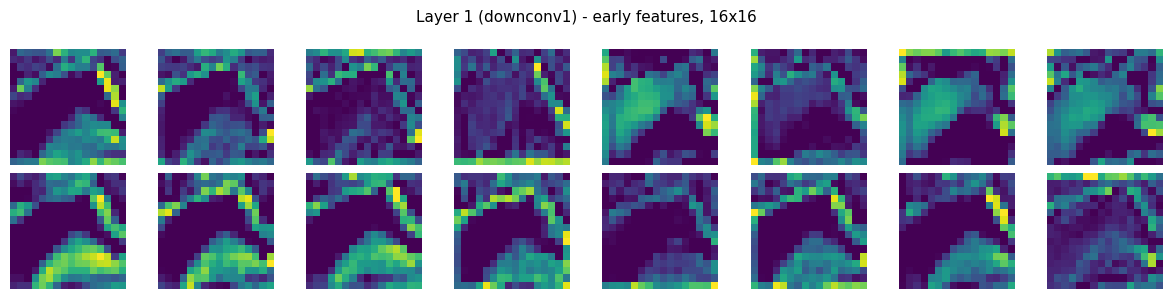

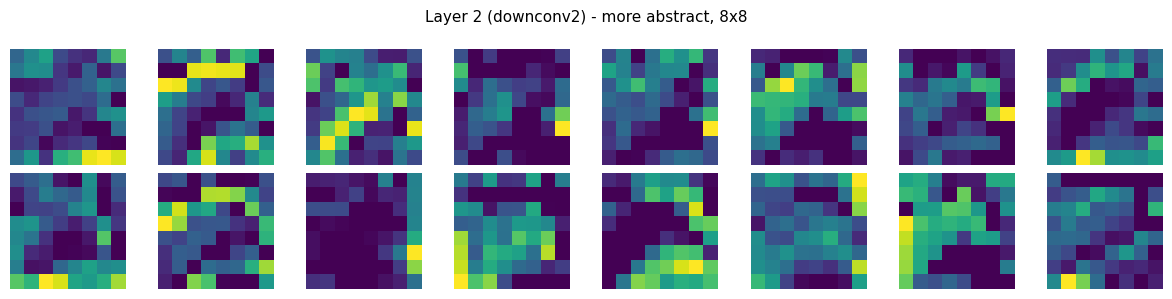

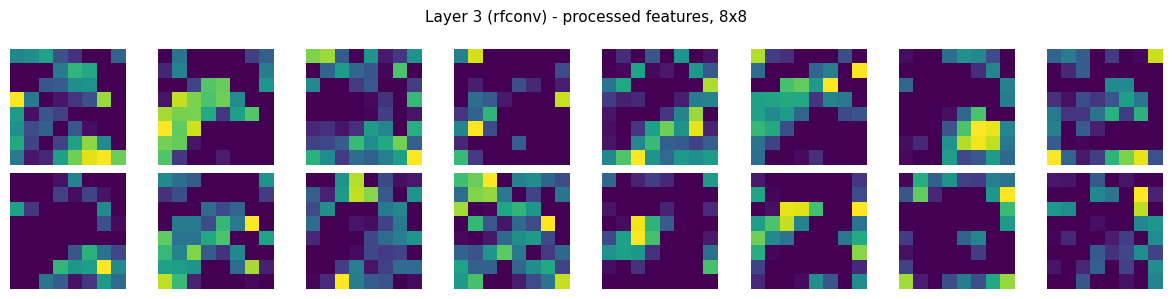

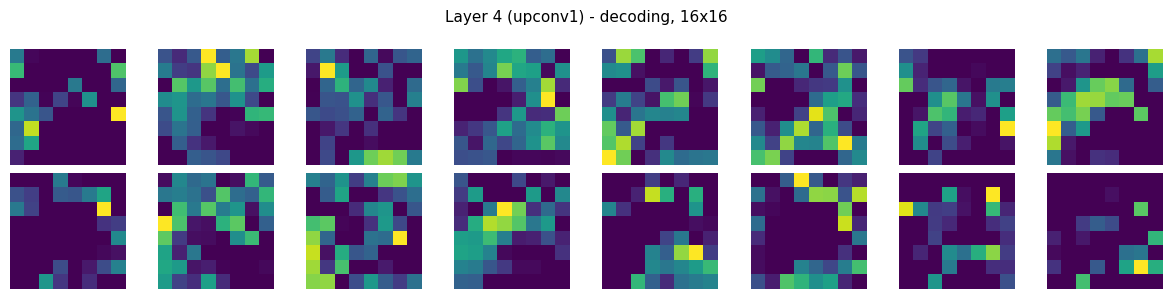

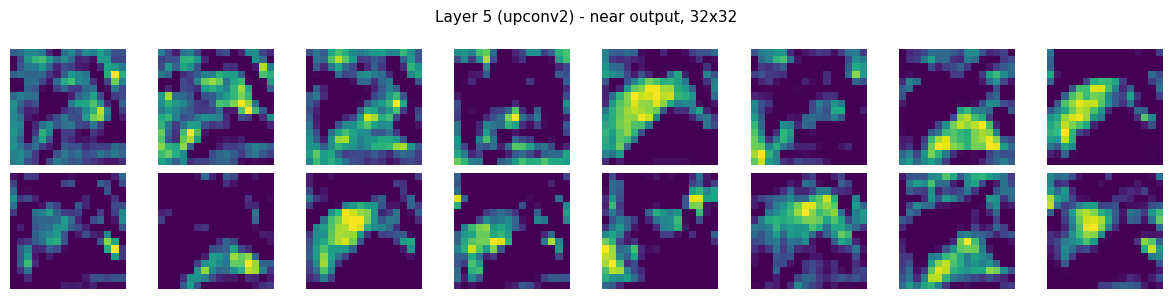

In [27]:
colours = np.load('./colour_kmeans24_cat7.npy', allow_pickle=True, encoding='latin1')[0]
(x_train, y_train), (x_test, y_test) = load_cifar10()
test_rgb, test_grey = process(x_test, y_test)
test_rgb_cat = get_rgb_cat(test_rgb, colours)

print('Activations for CNN:')
visualize_activations(cnn_model, test_grey, test_rgb_cat, colours, idx=0)

Activations for UNet:


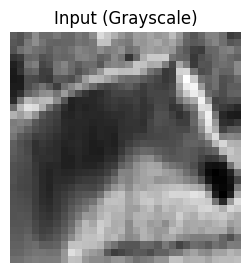

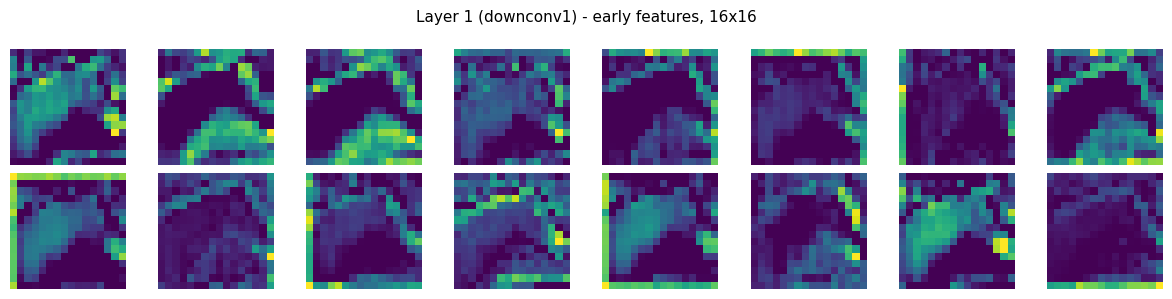

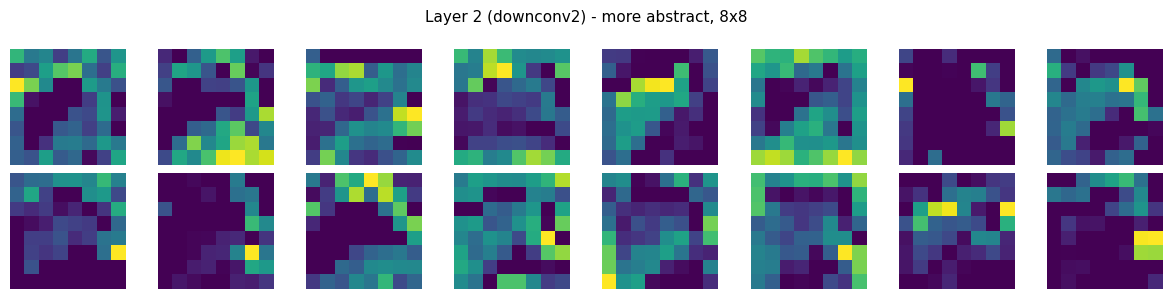

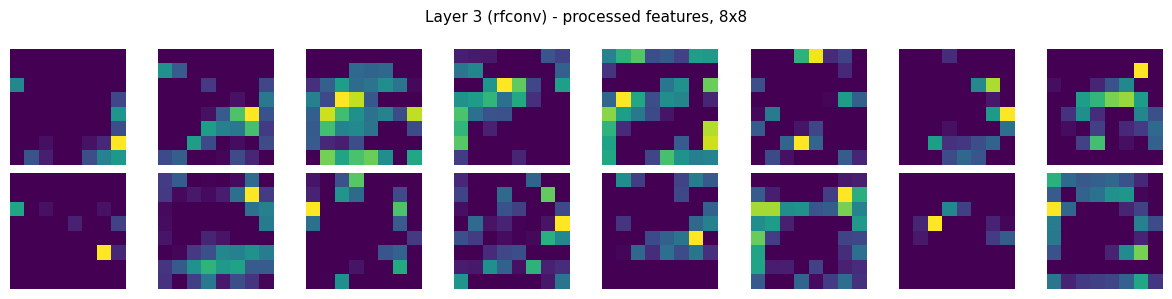

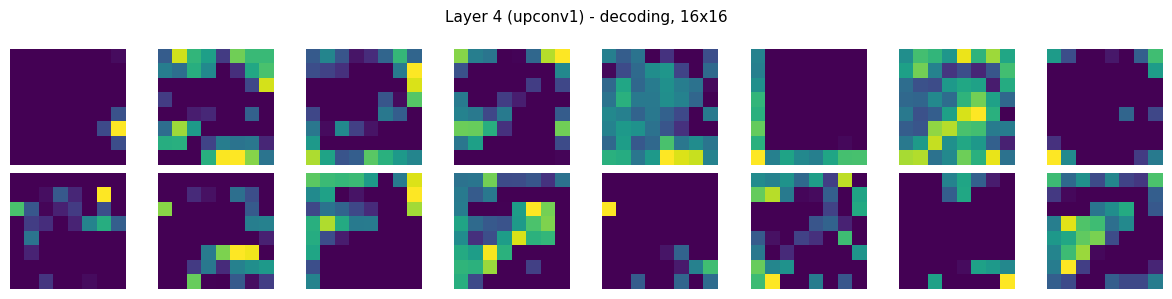

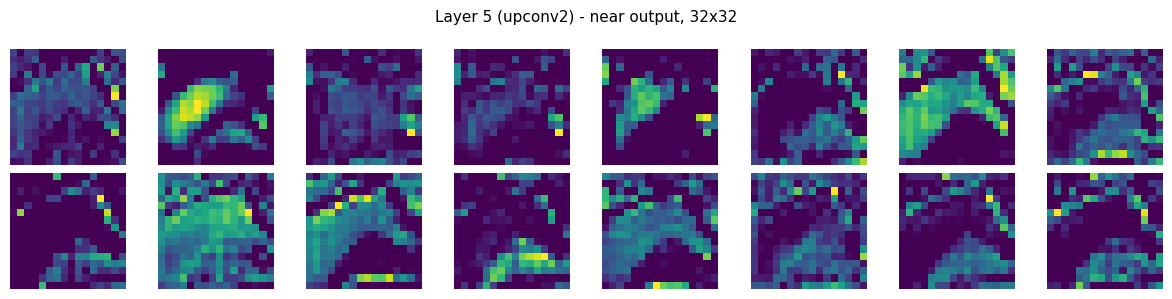

In [28]:
print('Activations for UNet:')
visualize_activations(unet_model, test_grey, test_rgb_cat, colours, idx=0)

## Theory Questions

### Q1: Regression CNN :Convolution Layers

**How many convolution layers are in the regression CNN?**

There are **6 convolution layers** total (5 nn.Conv2d + 1 MyConv2d). With `num_filters=32` and `kernel=3`:

| Layer | Type | In Channels | Out Channels | Kernel | Notes |
|-------|------|------------|-------------|--------|-------|
| downconv1 | Conv2d | 1 | 32 | 3×3 | + BN + ReLU + MaxPool |
| downconv2 | Conv2d | 32 | 64 | 3×3 | + BN + ReLU + MaxPool |
| rfconv | Conv2d | 64 | 64 | 3×3 | + BN + ReLU |
| upconv1 | Conv2d | 64 | 32 | 3×3 | + BN + ReLU + Upsample |
| upconv2 | Conv2d | 32 | 3 | 3×3 | + BN + ReLU + Upsample |
| finalconv | **MyConv2d** | 3 | 3 | 3×3 | output |

All filters are 3×3. The number of filters goes: 32, 64, 64, 32, 3, 3.


### Q2: Training Epochs Analysis

The regression CNN was trained for **25 epochs** by default.

When trained with fewer epochs (e.g. 5), the images look much worse mostly grayish-brown with very little colour variation. This makes sense because the model hasn't had time to learn the relationship between grayscale intensity and the colour that should be there. After 25 epochs the loss is lower and the images look more plausible, though regression still tends to produce "safe" averaged-out colors because MSE penalizes extreme predictions.


### Q3: Classification vs Regression : Which is Better?

Classification generally produces better looking colorizations. The main reason is that MSE loss encourages the network to predict the *average* of all possible colours (which tends to be a grayish brown), while CrossEntropy loss forces it to commit to a specific colour category. This is why classification outputs tend to have more saturated and varied colours even if they're not always the right ones.

In terms of numbers, the classification model also gives us an explicit accuracy metric (which colour category did we get right) which regression doesn't directly have.

### Q4: Skip Connections : Did They Help?

Yes. The UNet model generally achieves a lower validation loss and higher accuracy than the plain CNN. The colorizations also look qualitatively better the colors align more closely with the actual shapes in the image (e.g. the background gets a different color than the horse).

**Two reasons skip connections help:**
1. **Gradient flow:** In deep networks, gradients can vanish before reaching early layers. Skip connections provide a direct path for gradients to flow back, making training of early layers more effective.
2. **Preserving spatial information:** Downsampling loses high frequency spatial detail. Skip connections let the decoder access the original high resolution feature maps from the encoder, which helps place colours accurately at the right locations in the image.

### Q5: CNN vs UNet Activations : Observations

**CNN activations:**  
Early layers (out1, out2) show clear edge and texture detectors different filters respond to horizontal edges, vertical edges, corners etc. As we go deeper (out3) the activations become more abstract and harder to visually interpret. The upsampling layers (out4, out5) show smoother patterns as the network tries to reconstruct the spatial layout.

**UNet activations:**  
The encoder activations look similar to the CNN. However, the decoder layers (out4, out5) look noticeably different, they contain much more fine grained spatial structure because of the skip connections. The activations in the UNet decoder actually look more like the input image in terms of spatial sharpness, whereas the CNN decoder activations look blurrier. This aligns with why UNet produces better colorizations.

### Q6: Improving Evaluation Metrics

Pixel-level loss (MSE or CrossEntropy) doesn't necessarily reflect how good an image looks to a human. For example, a slightly shifted but otherwise correct colorization gets punished harshly by MSE even though it looks fine.

Better alternatives:
- **Perceptual loss** (Johnson et al. 2016): instead of comparing pixel values directly, compare the feature representations from a pretrained network (like VGG). This captures high level structure and texture similarity better.
- **SSIM (Structural Similarity):** measures structural and luminance similarity rather than pixel wise differences, which correlates better with human perception.
- **FID (Fréchet Inception Distance):** compares the distribution of generated images to real images in a feature space, which is better for evaluating overall image quality.


### Q7: Generalizing to Larger Images

Our models were trained on 32×32 images. To colorize larger images there are a few options:

1. **Fully convolutional networks** Our architecture is already mostly fully convolutional (no fully connected layers), which means it can technically be applied to any input size at test time. The MaxPool and Upsample operations work on any spatial size. We'd just need to make sure the final output size matches the input.
2. **Sliding window / patch based inference**  Split the larger image into 32×32 patches, colorize each one independently, and stitch back together. This has the downside of potential boundary artifacts.
3. **Fine tuning on larger images**  Retrain or fine tune the model on higher resolution images if we have them available.